![](images/Coexistence-logo.png)

> ERC Starting Grant on COeXISTENCE between humans and machines in urban mobility.


# Milestone 1

<img src="images/img_mileston1.png" alt="Milestone 1 Image" width="500" height="400">

# Title: Training using Torchrl library on our PettingZoo environment
## Name: Anastasia
### Date: April 17, 2024
---

### Description

> In this notebook, we implement the Proximal Policy Optimization (PPO) algorithm on the PettingZoo environment that we've already set up.
---

## Objective

> The purpose of this notebook is to gain a comprehensive understanding of the torchrl library and explore each of its components thoroughly.
---

## Experiment Summary

### Network Architecture
- Csomor network


### Agents
| **Type**          | Altruistic          |
|-------------------|---------------------|
| **Number**        | 200 humans, 1 machine |
| **Total demand** | 6 steps |


### Origin and Destination Details
| **Origin Count**      | 2                            |
|-----------------------|------------------------------|
| **Destination Count** | 2                            |
| **Origin Pairing**    | 279952229#0, 115604053       |
| **Destination Pairing**| -115602933#2, -441496282#1     |

    

### Hardware Utilized for Experiment Execution
| **Type of Machine** | Personal computer (or server) |
|----------------------|-------------------------------|
| **CPU**              | 12th Gen Intel(R) Core(TM) i7-1255U |
|                      | Cores: 10                   |
|                      | Sockets: 1                  |
|                      | Base Speed: 1.70 GHz        |
| **Memory**           | 16GB                          |
| **Disc (SSD)**       | 477 GB                        |
| **Operating System** | Windows 11                    |


## Implementation Time

| Parameter         | Value   |
|-------------------|---------|
| frames_per_batch  | 6       |
| n_iters           | 10      |
| total_frames      | 60      |
| Run Time | 2min 45.5s |


### Imported libraries 

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
from utilities import confirm_env_variable
from utilities import get_params
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from pettingzoo.test import parallel_api_test
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import os
import torch as th
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torchrl.envs import (
    Compose,
    DoubleToFloat,
    ObservationNorm,
    StepCounter,
    TransformedEnv,
)
from tensordict.nn.distributions import NormalParamExtractor
import torch
from torch import nn
from tensordict.nn import TensorDictModule, CompositeDistribution
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torch.distributions import Categorical

from torchrl.collectors import SyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (
    Compose,
    DoubleToFloat,
    ObservationNorm,
    StepCounter,
    TransformedEnv,
)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, TanhNormal, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from tqdm import tqdm
# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor, TanhNormal, Actor, OneHotCategorical, TanhDelta
from torchrl.objectives import ClipPPOLoss, ValueEstimators
import matplotlib.pyplot as plt
from torchrl.data import OneHotDiscreteTensorSpec
import torch
from torch.utils.tensorboard import SummaryWriter
from torchrl.modules.tensordict_module.actors import QValueActor
from torch.distributions import Normal

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


### Hyperparameters specification

In [2]:
# Devices
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 6  # Number of team frames collected per training iteration
n_iters = 10  # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 30  # Number of optimization steps per training iteration
minibatch_size = 400  # Size of the mini-batches in each optimization step
lr = 3e-4  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
gamma = 0.9  # discount factor
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

### Environment Creation

In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])
print("[SUCCESS] Environment initiated!")

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: training_records\paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [3.5734093637454984, 2.067767106842737, 2.4242496998799523], (0, 1): [0.7676270508203282, 2.014985994397759, 1.6727891156462587], (1, 0): [2.049482585133998, 0.7396357391048572, 0.6873687704023294], (1, 1): [2.0346137303013356, 5.1089523642430335, 1.9872287143799205]}

[SUCCESS] Free flow times calculated!
[INFO] Free-flow times:  {(0, 0): [3.5734093637454984, 2.067767106842737, 2.4242496998799523], (0, 1): [0.7676270508203282, 2.014985994397759, 1.6727891156462587], (1, 0): [2.049482585133998, 0.7396357391048572, 0.6873687704023294], (1, 1): [2.0346137303013356, 5.1089523642430335, 1.9872287143799205]}
[SUCCESS] Generated agent data and saved to: training_records\agents_data.csv
[SUCCESS] Created agent objects (200)

Agent 0 has origin 1 and destination 0.


[SUCCESS] Environment in

### Alignment of our environment with the torchrl environment

In [5]:
## https://github.com/pytorch/rl/blob/main/torchrl/envs/libs/pettingzoo.py
env = PettingZooWrapper(
    env=env,
    return_state=True,
    use_mask=True,
    group_map=None, # Use default for parallel
    categorical_actions=True,
)
print("env is: ", env)

env is:  PettingZooWrapper()


In [6]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: CompositeSpec(
    1: CompositeSpec(
        action: DiscreteTensorSpec(
            shape=torch.Size([1]),
            space=DiscreteBox(n=3),
            device=cpu,
            dtype=torch.int64,
            domain=discrete), device=cpu, shape=torch.Size([1])), device=cpu, shape=torch.Size([]))
reward_spec: CompositeSpec(
    1: CompositeSpec(
        reward: UnboundedContinuousTensorSpec(
            shape=torch.Size([1, 1]),
            space=None,
            device=cpu,
            dtype=torch.float32,
            domain=continuous), device=cpu, shape=torch.Size([1])), device=cpu, shape=torch.Size([]))
done_spec: CompositeSpec(
    done: DiscreteTensorSpec(
        shape=torch.Size([1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    terminated: DiscreteTensorSpec(
        shape=torch.Size([1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    trun

> The reward and action spec present the "agent" key, meaning that entries in tensordicts belonging to those specs will be nested in an “agents” tensordict, grouping all per-agent values.

> We can access the keys for each of these values in tensordicts, by asking the environment for the respective keys and this will help us understand which are per-agent and which shared.

In [7]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('1', 'action')]
reward_keys: [('1', 'reward')]
done_keys: ['done', 'terminated', 'truncated', ('1', 'done'), ('1', 'terminated'), ('1', 'truncated')]


### Transforms

> This will modify the inputs and outputs of our environment and will sum rewards over the episodes.


> We will tell the transform where to find the reward key and where to write the sum over episode reward.


> The transformed environment will inherit the device and meta-data of the wrapped environment and transform these depending on the sequence of transforms it contains.

In [8]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("1", "episode_reward")]),
)

print("Environment group mapping", env.group_map)

Environment group mapping {'1': ['1']}


In [9]:
check_env_specs(env)

2024-04-19 12:35:54,600 [torchrl][INFO] check_env_specs succeeded!


observation dict is:  {'1': array([30, 16, 11])} 




### Rollout

In [10]:
rollout = env.rollout(20)
print("rollout of twenty step:", rollout)

observation dict is:  {'1': array([17, 20, 20])} 


rollout of twenty step: TensorDict(
    fields={
        1: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1, 1]),
            device=cpu,
            is

In [11]:
print("Shape of the rollout TensorDict:", rollout.batch_size)

Shape of the rollout TensorDict: torch.Size([1])


In [12]:
print(rollout["1"])

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        episode_reward: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        mask: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([1, 1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([1, 1]),
    device=cpu,
    is_shared=False)


In [13]:
env.action_spec[-1]

DiscreteTensorSpec(
    shape=torch.Size([]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.int64,
    domain=discrete)

### Creation of the actor/policy neural network

In [14]:
share_parameters_policy = True

policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=env.observation_spec["1", "observation"].shape[-1],  # n_obs_per_agent
        n_agent_outputs=2 * env.action_spec.shape[-1],  # 2 * n_actions_per_agents
        n_agents=env.n_agents,
        centralised=False,  # the policies are decentralised (ie each agent will act from its observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.ReLU,
    ),
    NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

In [15]:
print(policy_net)

Sequential(
  (0): MultiAgentMLP(
    (agent_networks): ModuleList(
      (0): MLP(
        (0): Linear(in_features=3, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=2, bias=True)
      )
    )
  )
  (1): NormalParamExtractor()
)


In [16]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "loc"), ("1", "scale")],
)

In [17]:
print(policy_module)

TensorDictModule(
    module=Sequential(
      (0): MultiAgentMLP(
        (agent_networks): ModuleList(
          (0): MLP(
            (0): Linear(in_features=3, out_features=256, bias=True)
            (1): ReLU()
            (2): Linear(in_features=256, out_features=256, bias=True)
            (3): ReLU()
            (4): Linear(in_features=256, out_features=2, bias=True)
          )
        )
      )
      (1): NormalParamExtractor()
    ),
    device=cpu,
    in_keys=[('1', 'observation')],
    out_keys=[('1', 'loc'), ('1', 'scale')])


In [18]:
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=[("1", "loc"), ("1", "scale")],
    out_keys=[env.action_key],
    distribution_class=Normal,
    #distribution_class=CompositeDistribution,
    #return_log_prob=True,
    #safe=True,
    log_prob_key=("1", "sample_log_prob"),
)  # we'll need the log-prob for the PPO loss

In [19]:
print(policy)

ProbabilisticActor(
    module=ModuleList(
      (0): TensorDictModule(
          module=Sequential(
            (0): MultiAgentMLP(
              (agent_networks): ModuleList(
                (0): MLP(
                  (0): Linear(in_features=3, out_features=256, bias=True)
                  (1): ReLU()
                  (2): Linear(in_features=256, out_features=256, bias=True)
                  (3): ReLU()
                  (4): Linear(in_features=256, out_features=2, bias=True)
                )
              )
            )
            (1): NormalParamExtractor()
          ),
          device=cpu,
          in_keys=[('1', 'observation')],
          out_keys=[('1', 'loc'), ('1', 'scale')])
      (1): SafeProbabilisticModule()
    ),
    device=cpu,
    in_keys=[('1', 'observation')],
    out_keys=[('1', 'loc'), ('1', 'scale'), ('1', 'action')])


In [20]:
print("Running policy:", policy(env.reset()))

Running policy: TensorDict(
    fields={
        1: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                loc: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                scale: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1,

### Creation of the critic neural network

In [21]:
share_parameters_critic = True
mappo = True  # IPPO if False

critic_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["1", "observation"].shape[-1],
    n_agent_outputs=1,  # 1 value per agent
    n_agents=env.n_agents,
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

critic = TensorDictModule(
    module=critic_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "state_value")],
)

In [22]:
print("Running value:", critic(env.reset()))

Running value: TensorDict(
    fields={
        1: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                state_value: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dty

### Collector

In [23]:
collector = SyncDataCollector(
    env,
    policy,
    device=device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    reset_at_each_iter=False,
    total_frames=total_frames,
)

### Replay Buffer

In [24]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),  # We store the frames_per_batch collected at each iteration
    sampler=SamplerWithoutReplacement(),
    batch_size=minibatch_size,  # We will sample minibatches of this size
)

### PPO loss function

In [25]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coef=entropy_eps,
    normalize_advantage=False,  # Important to avoid normalizing across the agent dimension
)
loss_module.set_keys(  # We have to tell the loss where to find the keys
    reward=env.reward_key,
    action=env.action_key,
    sample_log_prob=("1", "sample_log_prob"),
    value=("1", "state_value"),
    # These last 2 keys will be expanded to match the reward shape
    done=("1", "done"),
    terminated=("1", "terminated"),
)


loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)  # We build GAE
GAE = loss_module.value_estimator

optim = torch.optim.Adam(loss_module.parameters(), lr)

In [26]:
writer = SummaryWriter('/runs')

### Training loop

episode_reward_mean = 0:   0%|          | 0/10 [00:00<?, ?it/s]

observation dict is:  {'1': array([19, 21, 17])} 


observation dict is:  {'1': array([15, 17, 25])} 


observation dict is:  {'1': array([18, 19, 20])} 


observation dict is:  {'1': array([16, 21, 20])} 


observation dict is:  {'1': array([19, 19, 19])} 




episode_reward_mean = -4.070797443389893:  10%|█         | 1/10 [00:12<01:54, 12.72s/it]

observation dict is:  {'1': array([16, 21, 20])} 


observation dict is:  {'1': array([14, 26, 17])} 


observation dict is:  {'1': array([15, 21, 21])} 


observation dict is:  {'1': array([16, 16, 25])} 


observation dict is:  {'1': array([15, 21, 21])} 


observation dict is:  {'1': array([13, 20, 24])} 




episode_reward_mean = -3.9398632049560547:  20%|██        | 2/10 [00:24<01:36, 12.12s/it]

...

observation dict is:  {'1': array([14, 22, 21])} 


observation dict is:  {'1': array([ 9, 19, 29])} 


observation dict is:  {'1': array([14, 24, 19])} 


observation dict is:  {'1': array([12, 19, 26])} 


observation dict is:  {'1': array([ 9, 22, 26])} 


observation dict is:  {'1': array([ 9, 29, 19])} 




episode_reward_mean = -3.5502536296844482:  80%|████████  | 8/10 [01:36<00:24, 12.29s/it]

observation dict is:  {'1': array([ 8, 29, 20])} 


observation dict is:  {'1': array([11, 20, 26])} 


observation dict is:  {'1': array([12, 24, 21])} 


observation dict is:  {'1': array([12, 26, 19])} 


observation dict is:  {'1': array([12, 21, 24])} 


observation dict is:  {'1': array([12, 29, 16])} 




episode_reward_mean = -3.519378662109375:  90%|█████████ | 9/10 [01:47<00:12, 12.02s/it] 

observation dict is:  {'1': array([ 9, 22, 26])} 


observation dict is:  {'1': array([10, 27, 20])} 


observation dict is:  {'1': array([ 8, 24, 25])} 


observation dict is:  {'1': array([ 7, 28, 22])} 


observation dict is:  {'1': array([ 7, 29, 21])} 


observation dict is:  {'1': array([ 8, 27, 22])} 


observation dict is:  {'1': array([10, 19, 28])} 




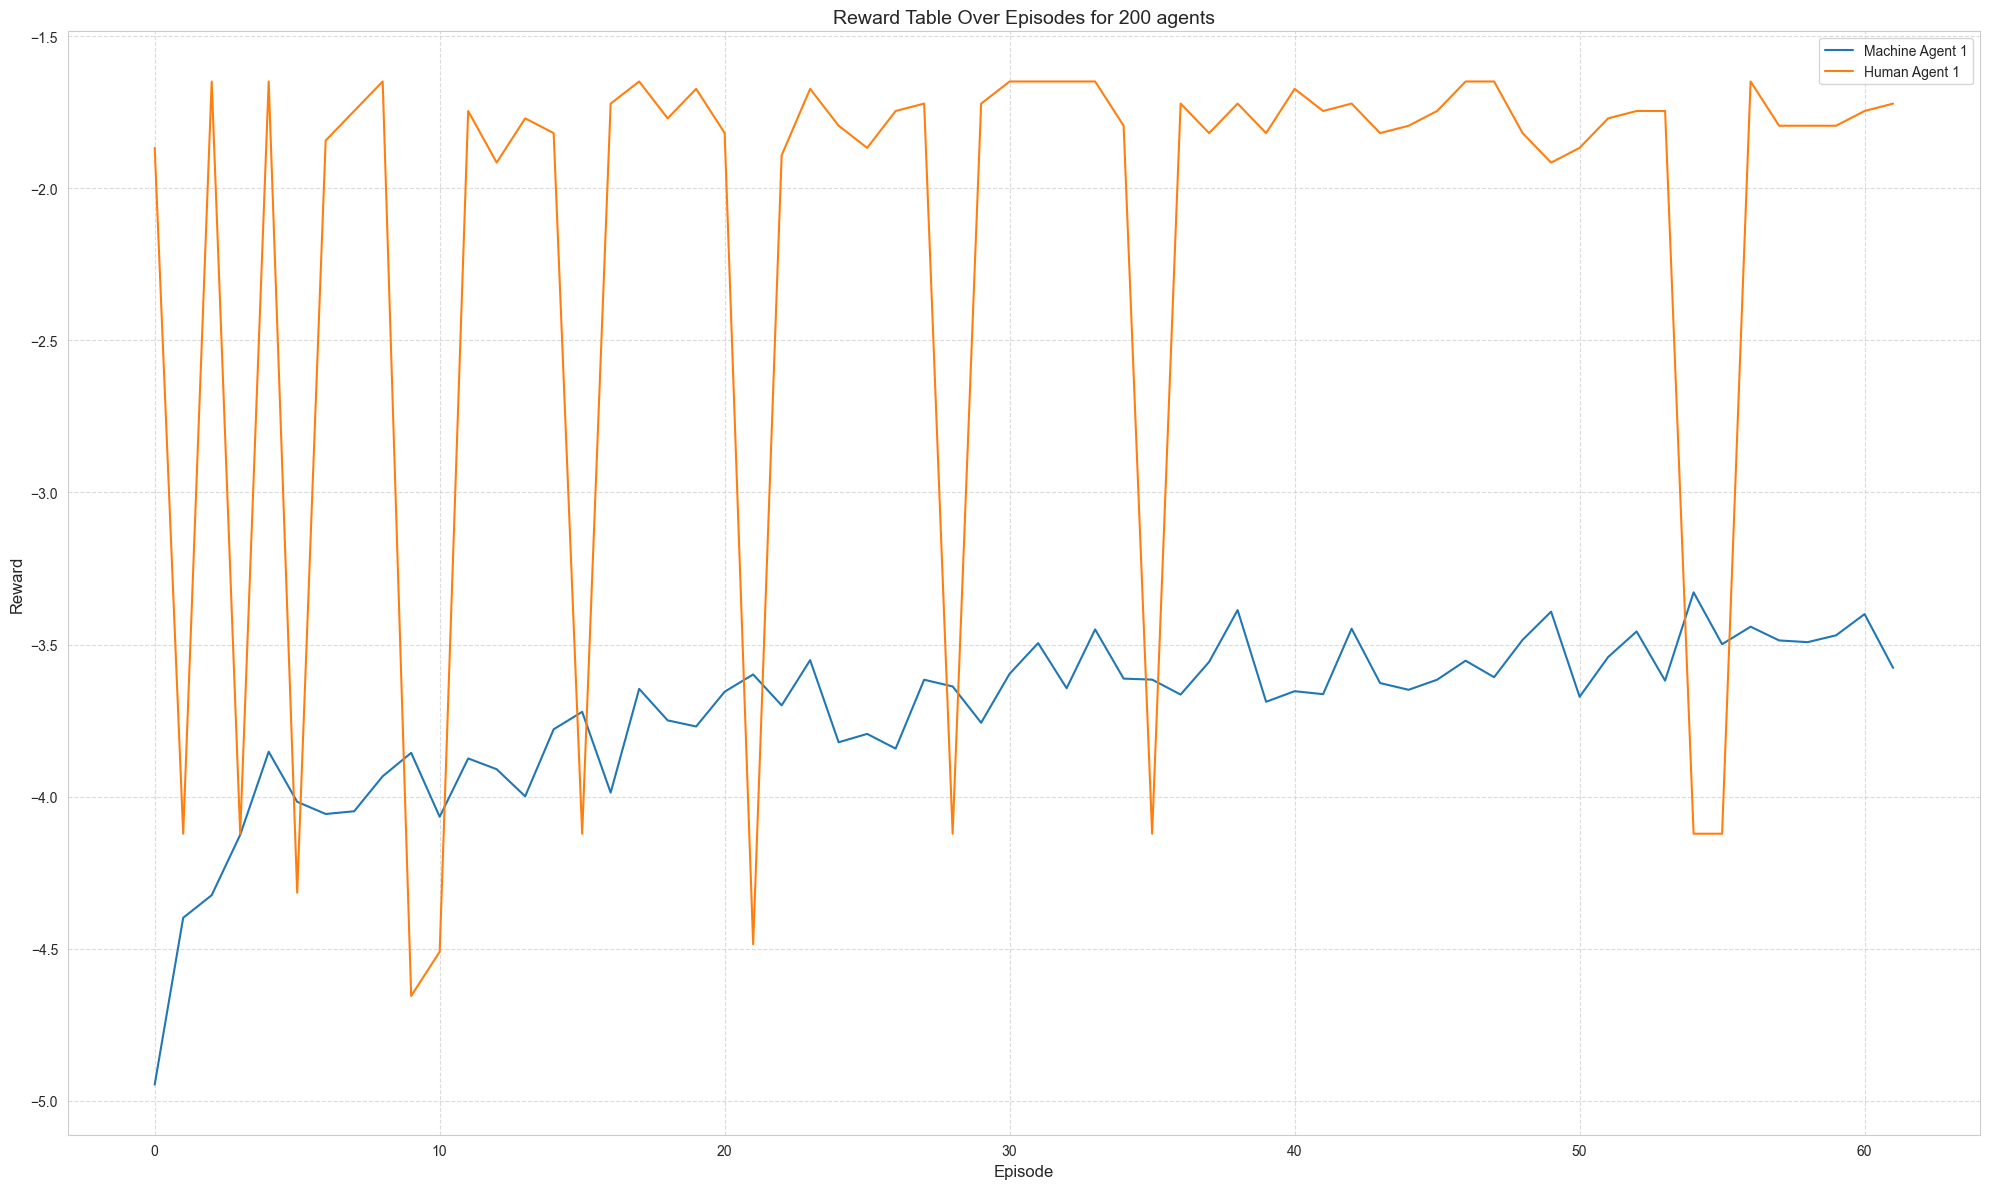

episode_reward_mean = -3.477754592895508: 100%|██████████| 10/10 [02:02<00:00, 12.74s/it]

In [27]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    tensordict_data.set(
        ("next", "1", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    tensordict_data.set(
        ("next", "1", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    # We need to expand the done and terminated to match the reward shape (this is expected by the value estimator)

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )  # Compute GAE and add it to the data

    data_view = tensordict_data.reshape(-1)  # Flatten the batch size to shuffle data
    replay_buffer.extend(data_view)


    for epoch in range(num_epochs):
        for _ in range(frames_per_batch // minibatch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()

            torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )  # Optional

            optim.step()
            optim.zero_grad()
            print("Loss/train", loss_value, epoch)
            writer.add_scalar("Loss/train", loss_value, epoch)

    collector.update_policy_weights_()

    # Logging
    done = tensordict_data.get(("next", "1", "done"))
    episode_reward_mean = (
        tensordict_data.get(("next", "1", "episode_reward"))[done].mean().item()
    )
    episode_reward_mean_list.append(episode_reward_mean)
    pbar.set_description(f"episode_reward_mean = {episode_reward_mean}", refresh=False)
    pbar.update()

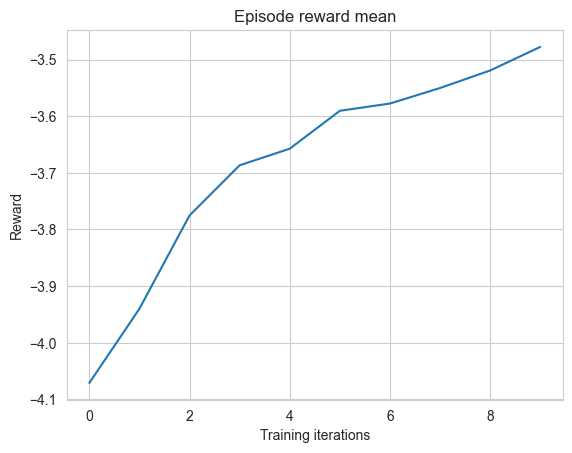

In [28]:
plt.plot(episode_reward_mean_list)
plt.xlabel("Training iterations")
plt.ylabel("Reward")
plt.title("Episode reward mean")
plt.show()

In [29]:
writer.flush()

In [30]:
!tensorboard --inspect --logdir=board/

Processing event files... (this can take a few minutes)

No event files found within logdir board/


2024-04-19 12:38:05.742526: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-19 12:38:07.136236: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
